# Load dataset from roboflow

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="XXXX")
print(rf.workspace())

loading Roboflow workspace...
{
  "name": "Dinithis Workspace",
  "url": "dinithis-workspace-asfor",
  "projects": [
    "dinithis-workspace-asfor/construction-safety-monitor-9pv9m",
    "dinithis-workspace-asfor/construction-safety-monitornew"
  ]
}


In [6]:
from roboflow import Roboflow

rf = Roboflow(api_key="sxXhubg9RzVIK12sV1Ev")
project = rf.workspace("dinithis-workspace-asfor").project("construction-safety-monitornew")

version_info = project.get_version_information()
print(version_info)

loading Roboflow workspace...
loading Roboflow project...
[{'id': 'dinithis-workspace-asfor/construction-safety-monitornew/1', 'name': '1', 'created': 1775141241.587, 'images': 989, 'splits': {'valid': 195, 'test': 100, 'train': 694}, 'preprocessing': {'auto-orient': True, 'resize': {'format': 'Stretch to', 'width': 512, 'height': 512}}, 'augmentation': {}, 'exports': []}]


In [7]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="sxXhubg9RzVIK12sV1Ev")
project = rf.workspace("dinithis-workspace-asfor").project("construction-safety-monitornew")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 99.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to construction-safety-monitorNew-1 in yolov8:: 100%|██████████| 1983/1983 [00:00<00:00, 7940.22it/s]


In [54]:
import os

DATASET_ROOT = "/content/construction-safety-monitorNew-1"

splits = ["train", "valid", "test"]
total_images = 0
total_labels = 0

for split in splits:
    images_dir = os.path.join(DATASET_ROOT, split, "images")
    labels_dir = os.path.join(DATASET_ROOT, split, "labels")

    image_count = 0
    label_count = 0

    if os.path.exists(images_dir):
        image_count = len([
            f for f in os.listdir(images_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ])

    if os.path.exists(labels_dir):
        label_count = len([
            f for f in os.listdir(labels_dir)
            if f.lower().endswith(".txt")
        ])

    total_images += image_count
    total_labels += label_count

    print(f"{split.upper()}:")
    print(f"  Images = {image_count}")
    print(f"  Labels = {label_count}")
    print()

print("TOTAL:")
print(f"  Images = {total_images}")
print(f"  Labels = {total_labels}")

TRAIN:
  Images = 694
  Labels = 694

VALID:
  Images = 195
  Labels = 195

TEST:
  Images = 100
  Labels = 100

TOTAL:
  Images = 989
  Labels = 989


# Install & check the data


In [8]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.5 kB/s eta 0:00:00


In [9]:
import os

for root, dirs, files in os.walk("/content"):
    if "data.yaml" in files:
        print(os.path.join(root, "data.yaml"))

/content/construction-safety-monitorNew-1/data.yaml


In [11]:
DATA_YAML = "/content/construction-safety-monitorNew-1/data.yaml"

In [12]:
import yaml

with open(DATA_YAML, "r") as f:
    cfg = yaml.safe_load(f)

print(cfg)

{'names': ['helmet', 'vest'], 'nc': 2, 'roboflow': {'license': 'CC BY 4.0', 'project': 'construction-safety-monitornew', 'url': 'https://universe.roboflow.com/dinithis-workspace-asfor/construction-safety-monitornew/dataset/1', 'version': 1, 'workspace': 'dinithis-workspace-asfor'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


Train the model

In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=DATA_YAML,
    epochs=5,
    imgsz=640,
    batch=16,
    patience=10,
    workers=2,
    project="/content/runs",
    name="ppe_yolov8n"
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/construction-safety-monitorNew-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_yolov8n2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

validation

In [16]:
best_model = YOLO("/content/runs/ppe_yolov8n2/weights/best.pt")
metrics = best_model.val(data=DATA_YAML)
print(metrics)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1503.2±562.7 MB/s, size: 35.7 KB)
val: Scanning /content/construction-safety-monitorNew-1/valid/labels.cache... 195 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 48.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.0s/it 38.9s
                   all        195        690      0.839      0.741      0.836      0.528
                helmet        169        373      0.921      0.723      0.863      0.561
                  vest        164        317      0.756       0.76      0.809      0.496
Speed: 1.6ms preprocess, 178.6ms inference, 0.0ms loss, 12.0ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array(

testing

In [18]:
results = best_model.predict(
    source="/content/construction-safety-monitorNew-1/test/images",
    save=True,
    conf=0.25
)


image 1/100 /content/construction-safety-monitorNew-1/test/images/helmet_jacket_00134_jpg.rf.57272cff156c67f0b9885be3d6272a92.jpg: 640x640 1 helmet, 3 vests, 398.9ms
image 2/100 /content/construction-safety-monitorNew-1/test/images/helmet_jacket_00214_jpg.rf.a306ea399c8f94afd0676dbbefd3b2cd.jpg: 640x640 1 helmet, 1 vest, 229.1ms
image 3/100 /content/construction-safety-monitorNew-1/test/images/helmet_jacket_00366_jpg.rf.15d97c21b0face08de176eb39eda1f14.jpg: 640x640 1 helmet, 1 vest, 170.4ms
image 4/100 /content/construction-safety-monitorNew-1/test/images/helmet_jacket_00506_jpg.rf.53137211fd3b9019a9d83ca875289cfc.jpg: 640x640 2 vests, 166.9ms
image 5/100 /content/construction-safety-monitorNew-1/test/images/helmet_jacket_00515_jpg.rf.61908310dc680ae0fcf30a56a51c64d6.jpg: 640x640 2 helmets, 1 vest, 171.5ms
image 6/100 /content/construction-safety-monitorNew-1/test/images/helmet_jacket_00518_jpg.rf.1867d620170c995fb12966541afc466d.jpg: 640x640 1 helmet, 2 vests, 171.8ms
image 7/100 /co

In [19]:
import os

for root, dirs, files in os.walk("/content/runs"):
    for f in files:
        if f.endswith(".jpg") or f.endswith(".png"):
            print(os.path.join(root, f))

/content/runs/detect/val/BoxR_curve.png
/content/runs/detect/val/confusion_matrix_normalized.png
/content/runs/detect/val/confusion_matrix.png
/content/runs/detect/val/BoxPR_curve.png
/content/runs/detect/val/val_batch1_pred.jpg
/content/runs/detect/val/val_batch2_labels.jpg
/content/runs/detect/val/BoxF1_curve.png
/content/runs/detect/val/val_batch1_labels.jpg
/content/runs/detect/val/val_batch2_pred.jpg
/content/runs/detect/val/val_batch0_pred.jpg
/content/runs/detect/val/val_batch0_labels.jpg
/content/runs/detect/val/BoxP_curve.png
/content/runs/detect/predict/helmet_jacket_10073_jpg.rf.6809a3a1276fe05660f6db189a9a151b.jpg
/content/runs/detect/predict/helmet_jacket_01925_jpg.rf.2c61332f028f728cac6c0e1af548d56c.jpg
/content/runs/detect/predict/helmet_jacket_01302_jpg.rf.32b786dbcc9e39b6fc062bd45d1ae3d7.jpg
/content/runs/detect/predict/helmet_jacket_09783_jpg.rf.b05e32e61e7d6160bb6eab42b50dda85.jpg
/content/runs/detect/predict/helmet_jacket_10271_jpg.rf.666f4c57960c1f0e786720afe36c7d7

Final Inference

In [31]:
from ultralytics import YOLO
import cv2
import os
import math

PPE_MODEL_PATH = "/content/runs/ppe_yolov8n2/weights/best.pt"
INPUT_IMAGE = "/content/construction-safety-monitorNew-1/test/images/helmet_jacket_00518_jpg.rf.1867d620170c995fb12966541afc466d.jpg"
OUTPUT_IMAGE = "/content/TestingOutputs/output_result.jpg"

person_model = YOLO("yolov8n.pt")
ppe_model = YOLO(PPE_MODEL_PATH)

PERSON_CONF = 0.25
PPE_CONF = 0.25

COCO_PERSON_CLASS_ID = 0

HELMET_CLASS_ID = 0
VEST_CLASS_ID = 1


def box_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)


def point_in_region(px, py, region):
    x1, y1, x2, y2 = region
    return x1 <= px <= x2 and y1 <= py <= y2


def get_person_regions(person_box):
    x1, y1, x2, y2 = person_box
    h = y2 - y1

    # helmet search = top 35%
    helmet_region = (x1, y1, x2, y1 + 0.35 * h)

    # vest search = middle 25% to 80%
    vest_region = (x1, y1 + 0.25 * h, x2, y1 + 0.80 * h)

    return helmet_region, vest_region


def draw_box(img, box, label, color, thickness=2):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(
        img,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2,
        cv2.LINE_AA,
    )

img = cv2.imread(INPUT_IMAGE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

person_results = person_model.predict(source=img_rgb, conf=PERSON_CONF, verbose=False)[0]

person_boxes = []
if person_results.boxes is not None:
    for b in person_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        if cls_id == COCO_PERSON_CLASS_ID and conf >= PERSON_CONF:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            person_boxes.append([x1, y1, x2, y2, conf])

ppe_results = ppe_model.predict(source=img_rgb, conf=PPE_CONF, verbose=False)[0]

helmet_boxes = []
vest_boxes = []

if ppe_results.boxes is not None:
    for b in ppe_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        x1, y1, x2, y2 = b.xyxy[0].tolist()

        if cls_id == HELMET_CLASS_ID:
            helmet_boxes.append([x1, y1, x2, y2, conf])
        elif cls_id == VEST_CLASS_ID:
            vest_boxes.append([x1, y1, x2, y2, conf])

unsafe_found = False

for person in person_boxes:
    px1, py1, px2, py2, pconf = person
    person_box = (px1, py1, px2, py2)

    helmet_region, vest_region = get_person_regions(person_box)

    has_helmet = False
    has_vest = False

    for hb in helmet_boxes:
        cx, cy = box_center(hb[:4])
        if point_in_region(cx, cy, helmet_region):
            has_helmet = True
            break

    for vb in vest_boxes:
        cx, cy = box_center(vb[:4])
        if point_in_region(cx, cy, vest_region):
            has_vest = True
            break

    if has_helmet and has_vest:
        status = "COMPLIANT"
        color = (0, 255, 0)
    elif (not has_helmet) and has_vest:
        status = "NO_HELMET"
        color = (0, 165, 255)
        unsafe_found = True
    elif has_helmet and (not has_vest):
        status = "NO_VEST"
        color = (0, 165, 255)
        unsafe_found = True
    else:
        status = "NO_HELMET_NO_VEST"
        color = (0, 0, 255)
        unsafe_found = True

    draw_box(img, person_box, status, color, 2)

# Draw PPE boxes too
for hb in helmet_boxes:
    draw_box(img, hb[:4], "helmet", (255, 0, 0), 2)

for vb in vest_boxes:
    draw_box(img, vb[:4], "vest", (255, 255, 0), 2)

scene_label = "UNSAFE" if unsafe_found else "SAFE"
scene_color = (0, 0, 255) if unsafe_found else (0, 255, 0)

cv2.rectangle(img, (10, 10), (220, 60), scene_color, -1)
cv2.putText(
    img,
    scene_label,
    (20, 45),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.0,
    (255, 255, 255),
    2,
    cv2.LINE_AA,
)

cv2.imwrite(OUTPUT_IMAGE, img)
print("Saved to:", OUTPUT_IMAGE)
print("Persons:", len(person_boxes), "Helmets:", len(helmet_boxes), "Vests:", len(vest_boxes))
print("Scene status:", scene_label)

Saved to: /content/TestingOutputs/output_result.jpg
Persons: 2 Helmets: 1 Vests: 3
Scene status: UNSAFE


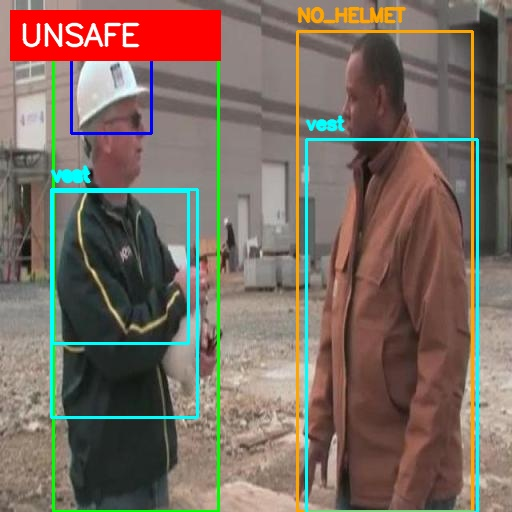

In [29]:
from IPython.display import Image, display
display(Image(filename="/content/TestingOutputs/output_result.jpg"))

sample2

In [40]:
from ultralytics import YOLO
import cv2
import os
import math

PPE_MODEL_PATH = "/content/runs/ppe_yolov8n2/weights/best.pt"
INPUT_IMAGE = "/content/construction-safety-monitorNew-1/test/images/helmet_jacket_01859_jpg.rf.e065ce4176099118513df04d36e5e7d9.jpg"
OUTPUT_IMAGE = "/content/TestingOutputs/output_result1.jpg"

person_model = YOLO("yolov8n.pt")
ppe_model = YOLO(PPE_MODEL_PATH)

PERSON_CONF = 0.25
PPE_CONF = 0.25

COCO_PERSON_CLASS_ID = 0

HELMET_CLASS_ID = 0
VEST_CLASS_ID = 1


def box_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)


def point_in_region(px, py, region):
    x1, y1, x2, y2 = region
    return x1 <= px <= x2 and y1 <= py <= y2


def get_person_regions(person_box):
    x1, y1, x2, y2 = person_box
    h = y2 - y1

    # helmet search = top 35%
    helmet_region = (x1, y1, x2, y1 + 0.35 * h)

    # vest search = middle 25% to 80%
    vest_region = (x1, y1 + 0.25 * h, x2, y1 + 0.80 * h)

    return helmet_region, vest_region


def draw_box(img, box, label, color, thickness=2):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(
        img,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2,
        cv2.LINE_AA,
    )

img = cv2.imread(INPUT_IMAGE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

person_results = person_model.predict(source=img_rgb, conf=PERSON_CONF, verbose=False)[0]

person_boxes = []
if person_results.boxes is not None:
    for b in person_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        if cls_id == COCO_PERSON_CLASS_ID and conf >= PERSON_CONF:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            person_boxes.append([x1, y1, x2, y2, conf])

ppe_results = ppe_model.predict(source=img_rgb, conf=PPE_CONF, verbose=False)[0]

helmet_boxes = []
vest_boxes = []

if ppe_results.boxes is not None:
    for b in ppe_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        x1, y1, x2, y2 = b.xyxy[0].tolist()

        if cls_id == HELMET_CLASS_ID:
            helmet_boxes.append([x1, y1, x2, y2, conf])
        elif cls_id == VEST_CLASS_ID:
            vest_boxes.append([x1, y1, x2, y2, conf])

unsafe_found = False

for person in person_boxes:
    px1, py1, px2, py2, pconf = person
    person_box = (px1, py1, px2, py2)

    helmet_region, vest_region = get_person_regions(person_box)

    has_helmet = False
    has_vest = False

    for hb in helmet_boxes:
        cx, cy = box_center(hb[:4])
        if point_in_region(cx, cy, helmet_region):
            has_helmet = True
            break

    for vb in vest_boxes:
        cx, cy = box_center(vb[:4])
        if point_in_region(cx, cy, vest_region):
            has_vest = True
            break

    if has_helmet and has_vest:
        status = "COMPLIANT"
        color = (0, 255, 0)
    elif (not has_helmet) and has_vest:
        status = "NO_HELMET"
        color = (0, 165, 255)
        unsafe_found = True
    elif has_helmet and (not has_vest):
        status = "NO_VEST"
        color = (0, 165, 255)
        unsafe_found = True
    else:
        status = "NO_HELMET_NO_VEST"
        color = (0, 0, 255)
        unsafe_found = True

    draw_box(img, person_box, status, color, 2)

# Draw PPE boxes too
for hb in helmet_boxes:
    draw_box(img, hb[:4], "helmet", (255, 0, 0), 2)

for vb in vest_boxes:
    draw_box(img, vb[:4], "vest", (255, 255, 0), 2)

scene_label = "UNSAFE" if unsafe_found else "SAFE"
scene_color = (0, 0, 255) if unsafe_found else (0, 255, 0)

cv2.rectangle(img, (10, 10), (220, 60), scene_color, -1)
cv2.putText(
    img,
    scene_label,
    (20, 45),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.0,
    (255, 255, 255),
    2,
    cv2.LINE_AA,
)

cv2.imwrite(OUTPUT_IMAGE, img)
print("Saved to:", OUTPUT_IMAGE)
print("Persons:", len(person_boxes), "Helmets:", len(helmet_boxes), "Vests:", len(vest_boxes))
print("Scene status:", scene_label)

Saved to: /content/TestingOutputs/output_result1.jpg
Persons: 2 Helmets: 2 Vests: 3
Scene status: SAFE


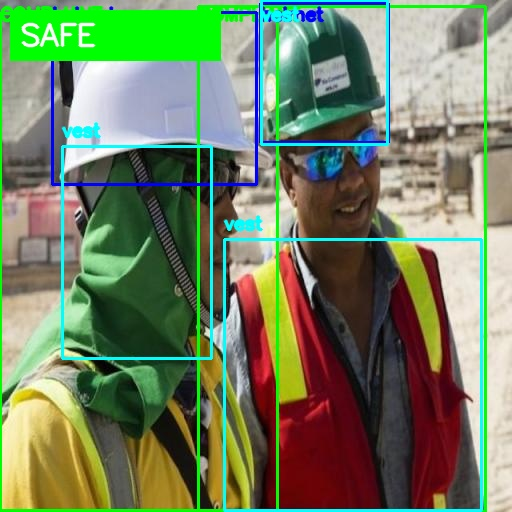

In [41]:
from IPython.display import Image, display
display(Image(filename="/content/TestingOutputs/output_result1.jpg"))

Final Inference version with confidence


Saved to: /content/TestingOutputs/NewTest1.jpg
Persons detected: 1
Helmets detected: 1
Vests detected: 3

--- Worker Report ---
Worker 1: COMPLIANT | person=0.25, helmet=0.85, vest=0.96

Scene status: SAFE
Scene confidence: 0.85


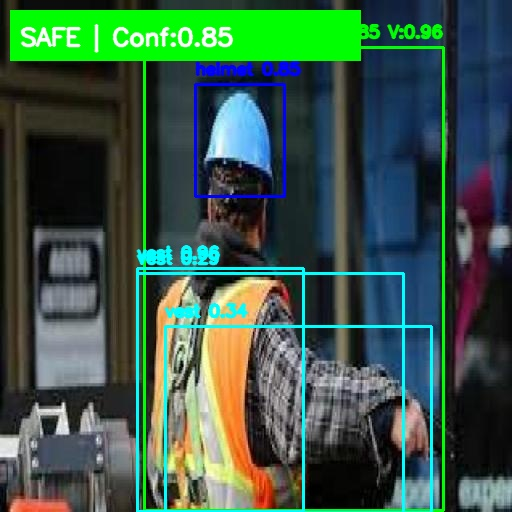

In [48]:
from ultralytics import YOLO
import cv2
import os
from IPython.display import Image, display

PPE_MODEL_PATH = "/content/runs/ppe_yolov8n2/weights/best.pt"
INPUT_IMAGE = "/content/construction-safety-monitorNew-1/test/images/helmet_jacket_06531_jpg.rf.fd4725ad3efe2ac2daa9ce224c310764.jpg"
OUTPUT_IMAGE = "/content/TestingOutputs/NewTest1.jpg"


PERSON_CONF = 0.25
PPE_CONF = 0.25

COCO_PERSON_CLASS_ID = 0

HELMET_CLASS_ID = 0
VEST_CLASS_ID = 1

person_model = YOLO("yolov8n.pt")
ppe_model = YOLO(PPE_MODEL_PATH)

def box_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)


def point_in_region(px, py, region):
    x1, y1, x2, y2 = region
    return x1 <= px <= x2 and y1 <= py <= y2


def get_person_regions(person_box):
    x1, y1, x2, y2 = person_box
    h = y2 - y1

    # Top region for helmet
    helmet_region = (x1, y1, x2, y1 + 0.35 * h)

    # Middle region for vest
    vest_region = (x1, y1 + 0.25 * h, x2, y1 + 0.80 * h)

    return helmet_region, vest_region


def draw_box(img, box, label, color, thickness=2):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(
        img,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        color,
        2,
        cv2.LINE_AA,
    )


img = cv2.imread(INPUT_IMAGE)
if img is None:
    raise FileNotFoundError(f"Could not read image: {INPUT_IMAGE}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


person_results = person_model.predict(
    source=img_rgb,
    conf=PERSON_CONF,
    verbose=False
)[0]

person_boxes = []
if person_results.boxes is not None:
    for b in person_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        if cls_id == COCO_PERSON_CLASS_ID and conf >= PERSON_CONF:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            person_boxes.append([x1, y1, x2, y2, conf])

ppe_results = ppe_model.predict(
    source=img_rgb,
    conf=PPE_CONF,
    verbose=False
)[0]

helmet_boxes = []
vest_boxes = []

if ppe_results.boxes is not None:
    for b in ppe_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        x1, y1, x2, y2 = b.xyxy[0].tolist()

        if cls_id == HELMET_CLASS_ID:
            helmet_boxes.append([x1, y1, x2, y2, conf])
        elif cls_id == VEST_CLASS_ID:
            vest_boxes.append([x1, y1, x2, y2, conf])


unsafe_found = False
worker_results = []

for person in person_boxes:
    px1, py1, px2, py2, pconf = person
    person_box = (px1, py1, px2, py2)

    helmet_region, vest_region = get_person_regions(person_box)

    has_helmet = False
    has_vest = False
    best_helmet_conf = 0.0
    best_vest_conf = 0.0

    for hb in helmet_boxes:
        cx, cy = box_center(hb[:4])
        if point_in_region(cx, cy, helmet_region):
            has_helmet = True
            best_helmet_conf = max(best_helmet_conf, hb[4])

    for vb in vest_boxes:
        cx, cy = box_center(vb[:4])
        if point_in_region(cx, cy, vest_region):
            has_vest = True
            best_vest_conf = max(best_vest_conf, vb[4])

    if has_helmet and has_vest:
        status = "COMPLIANT"
        color = (0, 255, 0)
        worker_conf = min(best_helmet_conf, best_vest_conf)
    elif (not has_helmet) and has_vest:
        status = "NO_HELMET"
        color = (0, 165, 255)
        worker_conf = best_vest_conf
        unsafe_found = True
    elif has_helmet and (not has_vest):
        status = "NO_VEST"
        color = (0, 165, 255)
        worker_conf = best_helmet_conf
        unsafe_found = True
    else:
        status = "NO_HELMET_NO_VEST"
        color = (0, 0, 255)
        worker_conf = pconf
        unsafe_found = True

    label = f"{status} | P:{pconf:.2f} H:{best_helmet_conf:.2f} V:{best_vest_conf:.2f}"
    draw_box(img, person_box, label, color, 2)

    worker_results.append({
        "status": status,
        "person_conf": pconf,
        "helmet_conf": best_helmet_conf,
        "vest_conf": best_vest_conf,
        "worker_conf": worker_conf
    })

for hb in helmet_boxes:
    draw_box(img, hb[:4], f"helmet {hb[4]:.2f}", (255, 0, 0), 2)

for vb in vest_boxes:
    draw_box(img, vb[:4], f"vest {vb[4]:.2f}", (255, 255, 0), 2)

scene_label = "UNSAFE" if unsafe_found else "SAFE"
scene_color = (0, 0, 255) if unsafe_found else (0, 255, 0)

if worker_results:
    scene_conf = max(w["worker_conf"] for w in worker_results)
else:
    scene_conf = 0.0

banner_text = f"{scene_label} | Conf:{scene_conf:.2f}"

cv2.rectangle(img, (10, 10), (360, 60), scene_color, -1)
cv2.putText(
    img,
    banner_text,
    (20, 45),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 255, 255),
    2,
    cv2.LINE_AA,
)

cv2.imwrite(OUTPUT_IMAGE, img)

print("Saved to:", OUTPUT_IMAGE)
print("Persons detected:", len(person_boxes))
print("Helmets detected:", len(helmet_boxes))
print("Vests detected:", len(vest_boxes))

print("\n--- Worker Report ---")
for i, w in enumerate(worker_results, 1):
    print(
        f"Worker {i}: {w['status']} | "
        f"person={w['person_conf']:.2f}, "
        f"helmet={w['helmet_conf']:.2f}, "
        f"vest={w['vest_conf']:.2f}"
    )

print(f"\nScene status: {scene_label}")
print(f"Scene confidence: {scene_conf:.2f}")

display(Image(filename=OUTPUT_IMAGE))

Saved to: /content/TestingOutputs/NewTest2.jpg
Persons detected: 1
Helmets detected: 2
Vests detected: 1

--- Worker Report ---
Worker 1: COMPLIANT | person=0.93, helmet=0.87, vest=0.56

Scene status: SAFE
Scene confidence: 0.56


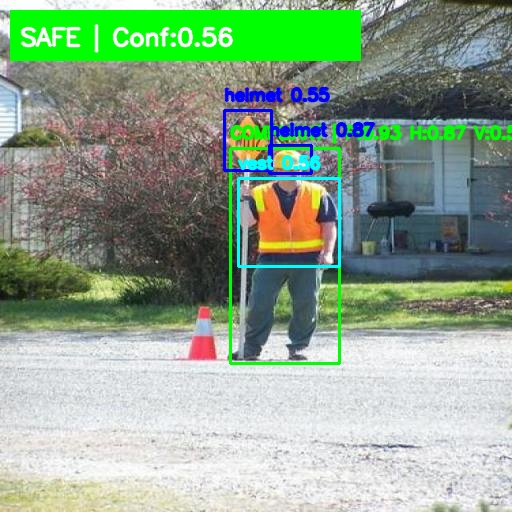

In [49]:
from ultralytics import YOLO
import cv2
import os
from IPython.display import Image, display

PPE_MODEL_PATH = "/content/runs/ppe_yolov8n2/weights/best.pt"
INPUT_IMAGE = "/content/construction-safety-monitorNew-1/test/images/helmet_jacket_09203_jpg.rf.561cbdb00b7e4e9ae1225be894a61af4.jpg"
OUTPUT_IMAGE = "/content/TestingOutputs/NewTest2.jpg"


PERSON_CONF = 0.25
PPE_CONF = 0.25

COCO_PERSON_CLASS_ID = 0

HELMET_CLASS_ID = 0
VEST_CLASS_ID = 1

person_model = YOLO("yolov8n.pt")
ppe_model = YOLO(PPE_MODEL_PATH)

def box_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)


def point_in_region(px, py, region):
    x1, y1, x2, y2 = region
    return x1 <= px <= x2 and y1 <= py <= y2


def get_person_regions(person_box):
    x1, y1, x2, y2 = person_box
    h = y2 - y1

    # Top region for helmet
    helmet_region = (x1, y1, x2, y1 + 0.35 * h)

    # Middle region for vest
    vest_region = (x1, y1 + 0.25 * h, x2, y1 + 0.80 * h)

    return helmet_region, vest_region


def draw_box(img, box, label, color, thickness=2):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(
        img,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        color,
        2,
        cv2.LINE_AA,
    )


img = cv2.imread(INPUT_IMAGE)
if img is None:
    raise FileNotFoundError(f"Could not read image: {INPUT_IMAGE}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


person_results = person_model.predict(
    source=img_rgb,
    conf=PERSON_CONF,
    verbose=False
)[0]

person_boxes = []
if person_results.boxes is not None:
    for b in person_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        if cls_id == COCO_PERSON_CLASS_ID and conf >= PERSON_CONF:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            person_boxes.append([x1, y1, x2, y2, conf])

ppe_results = ppe_model.predict(
    source=img_rgb,
    conf=PPE_CONF,
    verbose=False
)[0]

helmet_boxes = []
vest_boxes = []

if ppe_results.boxes is not None:
    for b in ppe_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        x1, y1, x2, y2 = b.xyxy[0].tolist()

        if cls_id == HELMET_CLASS_ID:
            helmet_boxes.append([x1, y1, x2, y2, conf])
        elif cls_id == VEST_CLASS_ID:
            vest_boxes.append([x1, y1, x2, y2, conf])


unsafe_found = False
worker_results = []

for person in person_boxes:
    px1, py1, px2, py2, pconf = person
    person_box = (px1, py1, px2, py2)

    helmet_region, vest_region = get_person_regions(person_box)

    has_helmet = False
    has_vest = False
    best_helmet_conf = 0.0
    best_vest_conf = 0.0

    for hb in helmet_boxes:
        cx, cy = box_center(hb[:4])
        if point_in_region(cx, cy, helmet_region):
            has_helmet = True
            best_helmet_conf = max(best_helmet_conf, hb[4])

    for vb in vest_boxes:
        cx, cy = box_center(vb[:4])
        if point_in_region(cx, cy, vest_region):
            has_vest = True
            best_vest_conf = max(best_vest_conf, vb[4])

    if has_helmet and has_vest:
        status = "COMPLIANT"
        color = (0, 255, 0)
        worker_conf = min(best_helmet_conf, best_vest_conf)
    elif (not has_helmet) and has_vest:
        status = "NO_HELMET"
        color = (0, 165, 255)
        worker_conf = best_vest_conf
        unsafe_found = True
    elif has_helmet and (not has_vest):
        status = "NO_VEST"
        color = (0, 165, 255)
        worker_conf = best_helmet_conf
        unsafe_found = True
    else:
        status = "NO_HELMET_NO_VEST"
        color = (0, 0, 255)
        worker_conf = pconf
        unsafe_found = True

    label = f"{status} | P:{pconf:.2f} H:{best_helmet_conf:.2f} V:{best_vest_conf:.2f}"
    draw_box(img, person_box, label, color, 2)

    worker_results.append({
        "status": status,
        "person_conf": pconf,
        "helmet_conf": best_helmet_conf,
        "vest_conf": best_vest_conf,
        "worker_conf": worker_conf
    })

for hb in helmet_boxes:
    draw_box(img, hb[:4], f"helmet {hb[4]:.2f}", (255, 0, 0), 2)

for vb in vest_boxes:
    draw_box(img, vb[:4], f"vest {vb[4]:.2f}", (255, 255, 0), 2)

scene_label = "UNSAFE" if unsafe_found else "SAFE"
scene_color = (0, 0, 255) if unsafe_found else (0, 255, 0)

if worker_results:
    scene_conf = max(w["worker_conf"] for w in worker_results)
else:
    scene_conf = 0.0

banner_text = f"{scene_label} | Conf:{scene_conf:.2f}"

cv2.rectangle(img, (10, 10), (360, 60), scene_color, -1)
cv2.putText(
    img,
    banner_text,
    (20, 45),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 255, 255),
    2,
    cv2.LINE_AA,
)

cv2.imwrite(OUTPUT_IMAGE, img)

print("Saved to:", OUTPUT_IMAGE)
print("Persons detected:", len(person_boxes))
print("Helmets detected:", len(helmet_boxes))
print("Vests detected:", len(vest_boxes))

print("\n--- Worker Report ---")
for i, w in enumerate(worker_results, 1):
    print(
        f"Worker {i}: {w['status']} | "
        f"person={w['person_conf']:.2f}, "
        f"helmet={w['helmet_conf']:.2f}, "
        f"vest={w['vest_conf']:.2f}"
    )

print(f"\nScene status: {scene_label}")
print(f"Scene confidence: {scene_conf:.2f}")

display(Image(filename=OUTPUT_IMAGE))

Saved to: /content/TestingOutputs/NewTest3.jpg
Persons detected: 1
Helmets detected: 1
Vests detected: 1

--- Worker Report ---
Worker 1: COMPLIANT | person=0.28, helmet=0.57, vest=0.69

Scene status: SAFE
Scene confidence: 0.57


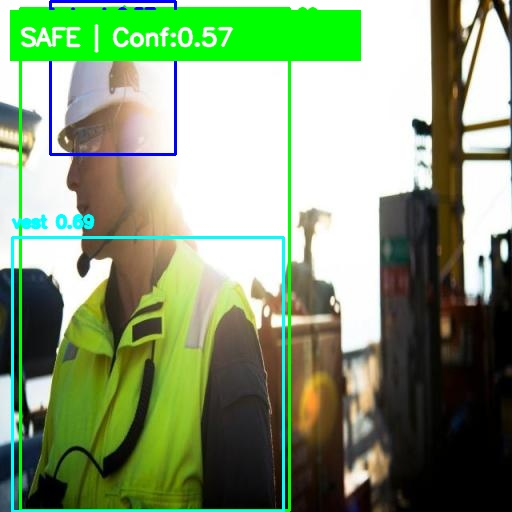

In [50]:
from ultralytics import YOLO
import cv2
import os
from IPython.display import Image, display

PPE_MODEL_PATH = "/content/runs/ppe_yolov8n2/weights/best.pt"
INPUT_IMAGE = "/content/construction-safety-monitorNew-1/test/images/helmet_jacket_06814_jpg.rf.8dc7791ac4ddd9ad728d739aeb793399.jpg"
OUTPUT_IMAGE = "/content/TestingOutputs/NewTest3.jpg"


PERSON_CONF = 0.25
PPE_CONF = 0.25

COCO_PERSON_CLASS_ID = 0

HELMET_CLASS_ID = 0
VEST_CLASS_ID = 1

person_model = YOLO("yolov8n.pt")
ppe_model = YOLO(PPE_MODEL_PATH)

def box_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)


def point_in_region(px, py, region):
    x1, y1, x2, y2 = region
    return x1 <= px <= x2 and y1 <= py <= y2


def get_person_regions(person_box):
    x1, y1, x2, y2 = person_box
    h = y2 - y1

    # Top region for helmet
    helmet_region = (x1, y1, x2, y1 + 0.35 * h)

    # Middle region for vest
    vest_region = (x1, y1 + 0.25 * h, x2, y1 + 0.80 * h)

    return helmet_region, vest_region


def draw_box(img, box, label, color, thickness=2):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(
        img,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        color,
        2,
        cv2.LINE_AA,
    )


img = cv2.imread(INPUT_IMAGE)
if img is None:
    raise FileNotFoundError(f"Could not read image: {INPUT_IMAGE}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


person_results = person_model.predict(
    source=img_rgb,
    conf=PERSON_CONF,
    verbose=False
)[0]

person_boxes = []
if person_results.boxes is not None:
    for b in person_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        if cls_id == COCO_PERSON_CLASS_ID and conf >= PERSON_CONF:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            person_boxes.append([x1, y1, x2, y2, conf])

ppe_results = ppe_model.predict(
    source=img_rgb,
    conf=PPE_CONF,
    verbose=False
)[0]

helmet_boxes = []
vest_boxes = []

if ppe_results.boxes is not None:
    for b in ppe_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        x1, y1, x2, y2 = b.xyxy[0].tolist()

        if cls_id == HELMET_CLASS_ID:
            helmet_boxes.append([x1, y1, x2, y2, conf])
        elif cls_id == VEST_CLASS_ID:
            vest_boxes.append([x1, y1, x2, y2, conf])


unsafe_found = False
worker_results = []

for person in person_boxes:
    px1, py1, px2, py2, pconf = person
    person_box = (px1, py1, px2, py2)

    helmet_region, vest_region = get_person_regions(person_box)

    has_helmet = False
    has_vest = False
    best_helmet_conf = 0.0
    best_vest_conf = 0.0

    for hb in helmet_boxes:
        cx, cy = box_center(hb[:4])
        if point_in_region(cx, cy, helmet_region):
            has_helmet = True
            best_helmet_conf = max(best_helmet_conf, hb[4])

    for vb in vest_boxes:
        cx, cy = box_center(vb[:4])
        if point_in_region(cx, cy, vest_region):
            has_vest = True
            best_vest_conf = max(best_vest_conf, vb[4])

    if has_helmet and has_vest:
        status = "COMPLIANT"
        color = (0, 255, 0)
        worker_conf = min(best_helmet_conf, best_vest_conf)
    elif (not has_helmet) and has_vest:
        status = "NO_HELMET"
        color = (0, 165, 255)
        worker_conf = best_vest_conf
        unsafe_found = True
    elif has_helmet and (not has_vest):
        status = "NO_VEST"
        color = (0, 165, 255)
        worker_conf = best_helmet_conf
        unsafe_found = True
    else:
        status = "NO_HELMET_NO_VEST"
        color = (0, 0, 255)
        worker_conf = pconf
        unsafe_found = True

    label = f"{status} | P:{pconf:.2f} H:{best_helmet_conf:.2f} V:{best_vest_conf:.2f}"
    draw_box(img, person_box, label, color, 2)

    worker_results.append({
        "status": status,
        "person_conf": pconf,
        "helmet_conf": best_helmet_conf,
        "vest_conf": best_vest_conf,
        "worker_conf": worker_conf
    })

for hb in helmet_boxes:
    draw_box(img, hb[:4], f"helmet {hb[4]:.2f}", (255, 0, 0), 2)

for vb in vest_boxes:
    draw_box(img, vb[:4], f"vest {vb[4]:.2f}", (255, 255, 0), 2)

scene_label = "UNSAFE" if unsafe_found else "SAFE"
scene_color = (0, 0, 255) if unsafe_found else (0, 255, 0)

if worker_results:
    scene_conf = max(w["worker_conf"] for w in worker_results)
else:
    scene_conf = 0.0

banner_text = f"{scene_label} | Conf:{scene_conf:.2f}"

cv2.rectangle(img, (10, 10), (360, 60), scene_color, -1)
cv2.putText(
    img,
    banner_text,
    (20, 45),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 255, 255),
    2,
    cv2.LINE_AA,
)

cv2.imwrite(OUTPUT_IMAGE, img)

print("Saved to:", OUTPUT_IMAGE)
print("Persons detected:", len(person_boxes))
print("Helmets detected:", len(helmet_boxes))
print("Vests detected:", len(vest_boxes))

print("\n--- Worker Report ---")
for i, w in enumerate(worker_results, 1):
    print(
        f"Worker {i}: {w['status']} | "
        f"person={w['person_conf']:.2f}, "
        f"helmet={w['helmet_conf']:.2f}, "
        f"vest={w['vest_conf']:.2f}"
    )

print(f"\nScene status: {scene_label}")
print(f"Scene confidence: {scene_conf:.2f}")

display(Image(filename=OUTPUT_IMAGE))

Saved to: /content/TestingOutputs/NewTest4.jpg
Persons detected: 3
Helmets detected: 3
Vests detected: 2

--- Worker Report ---
Worker 1: COMPLIANT | person=0.89, helmet=0.83, vest=0.85
Worker 2: COMPLIANT | person=0.63, helmet=0.90, vest=0.56
Worker 3: NO_VEST | person=0.41, helmet=0.78, vest=0.00

Scene status: UNSAFE
Scene confidence: 0.83


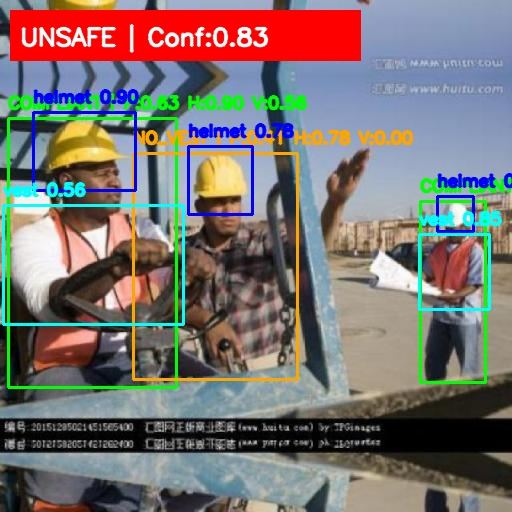

In [53]:
from ultralytics import YOLO
import cv2
import os
from IPython.display import Image, display

PPE_MODEL_PATH = "/content/runs/ppe_yolov8n2/weights/best.pt"
INPUT_IMAGE = "/content/construction-safety-monitorNew-1/test/images/helmet_jacket_09783_jpg.rf.b05e32e61e7d6160bb6eab42b50dda85.jpg"
OUTPUT_IMAGE = "/content/TestingOutputs/NewTest4.jpg"


PERSON_CONF = 0.25
PPE_CONF = 0.25

COCO_PERSON_CLASS_ID = 0

HELMET_CLASS_ID = 0
VEST_CLASS_ID = 1

person_model = YOLO("yolov8n.pt")
ppe_model = YOLO(PPE_MODEL_PATH)

def box_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)


def point_in_region(px, py, region):
    x1, y1, x2, y2 = region
    return x1 <= px <= x2 and y1 <= py <= y2


def get_person_regions(person_box):
    x1, y1, x2, y2 = person_box
    h = y2 - y1

    # Top region for helmet
    helmet_region = (x1, y1, x2, y1 + 0.35 * h)

    # Middle region for vest
    vest_region = (x1, y1 + 0.25 * h, x2, y1 + 0.80 * h)

    return helmet_region, vest_region


def draw_box(img, box, label, color, thickness=2):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(
        img,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        color,
        2,
        cv2.LINE_AA,
    )


img = cv2.imread(INPUT_IMAGE)
if img is None:
    raise FileNotFoundError(f"Could not read image: {INPUT_IMAGE}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


person_results = person_model.predict(
    source=img_rgb,
    conf=PERSON_CONF,
    verbose=False
)[0]

person_boxes = []
if person_results.boxes is not None:
    for b in person_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        if cls_id == COCO_PERSON_CLASS_ID and conf >= PERSON_CONF:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            person_boxes.append([x1, y1, x2, y2, conf])

ppe_results = ppe_model.predict(
    source=img_rgb,
    conf=PPE_CONF,
    verbose=False
)[0]

helmet_boxes = []
vest_boxes = []

if ppe_results.boxes is not None:
    for b in ppe_results.boxes:
        cls_id = int(b.cls.item())
        conf = float(b.conf.item())
        x1, y1, x2, y2 = b.xyxy[0].tolist()

        if cls_id == HELMET_CLASS_ID:
            helmet_boxes.append([x1, y1, x2, y2, conf])
        elif cls_id == VEST_CLASS_ID:
            vest_boxes.append([x1, y1, x2, y2, conf])


unsafe_found = False
worker_results = []

for person in person_boxes:
    px1, py1, px2, py2, pconf = person
    person_box = (px1, py1, px2, py2)

    helmet_region, vest_region = get_person_regions(person_box)

    has_helmet = False
    has_vest = False
    best_helmet_conf = 0.0
    best_vest_conf = 0.0

    for hb in helmet_boxes:
        cx, cy = box_center(hb[:4])
        if point_in_region(cx, cy, helmet_region):
            has_helmet = True
            best_helmet_conf = max(best_helmet_conf, hb[4])

    for vb in vest_boxes:
        cx, cy = box_center(vb[:4])
        if point_in_region(cx, cy, vest_region):
            has_vest = True
            best_vest_conf = max(best_vest_conf, vb[4])

    if has_helmet and has_vest:
        status = "COMPLIANT"
        color = (0, 255, 0)
        worker_conf = min(best_helmet_conf, best_vest_conf)
    elif (not has_helmet) and has_vest:
        status = "NO_HELMET"
        color = (0, 165, 255)
        worker_conf = best_vest_conf
        unsafe_found = True
    elif has_helmet and (not has_vest):
        status = "NO_VEST"
        color = (0, 165, 255)
        worker_conf = best_helmet_conf
        unsafe_found = True
    else:
        status = "NO_HELMET_NO_VEST"
        color = (0, 0, 255)
        worker_conf = pconf
        unsafe_found = True

    label = f"{status} | P:{pconf:.2f} H:{best_helmet_conf:.2f} V:{best_vest_conf:.2f}"
    draw_box(img, person_box, label, color, 2)

    worker_results.append({
        "status": status,
        "person_conf": pconf,
        "helmet_conf": best_helmet_conf,
        "vest_conf": best_vest_conf,
        "worker_conf": worker_conf
    })

for hb in helmet_boxes:
    draw_box(img, hb[:4], f"helmet {hb[4]:.2f}", (255, 0, 0), 2)

for vb in vest_boxes:
    draw_box(img, vb[:4], f"vest {vb[4]:.2f}", (255, 255, 0), 2)

scene_label = "UNSAFE" if unsafe_found else "SAFE"
scene_color = (0, 0, 255) if unsafe_found else (0, 255, 0)

if worker_results:
    scene_conf = max(w["worker_conf"] for w in worker_results)
else:
    scene_conf = 0.0

banner_text = f"{scene_label} | Conf:{scene_conf:.2f}"

cv2.rectangle(img, (10, 10), (360, 60), scene_color, -1)
cv2.putText(
    img,
    banner_text,
    (20, 45),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 255, 255),
    2,
    cv2.LINE_AA,
)

cv2.imwrite(OUTPUT_IMAGE, img)

print("Saved to:", OUTPUT_IMAGE)
print("Persons detected:", len(person_boxes))
print("Helmets detected:", len(helmet_boxes))
print("Vests detected:", len(vest_boxes))

print("\n--- Worker Report ---")
for i, w in enumerate(worker_results, 1):
    print(
        f"Worker {i}: {w['status']} | "
        f"person={w['person_conf']:.2f}, "
        f"helmet={w['helmet_conf']:.2f}, "
        f"vest={w['vest_conf']:.2f}"
    )

print(f"\nScene status: {scene_label}")
print(f"Scene confidence: {scene_conf:.2f}")

display(Image(filename=OUTPUT_IMAGE))

zip dataset and download

In [55]:
import shutil

folder_to_zip = "/content/construction-safety-monitorNew-1"
output_zip = "/content/dataset"

shutil.make_archive(output_zip, 'zip', folder_to_zip)
print("Created:", output_zip + ".zip")

Created: /content/dataset.zip


In [56]:
from google.colab import files

files.download("/content/dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>